In [49]:
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Création de données artificielles (2 dimensions)
np.random.seed(42)

X1 = np.random.randn(50, 2) + np.array([2, 2])
X2 = np.random.randn(50, 2) + np.array([-2, -2])
X3 = np.random.randn(50, 2) + np.array([2, -2])

# Fusion des données dans une seule matrice
X = np.vstack((X1, X2, X3))


In [51]:
def initialiser_centroides(X, k):
    """
    Choisit aléatoirement k points comme centres initiaux
    """
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]


In [52]:
def distance_euclidienne(x, c):
    """
    Calcule la distance euclidienne entre un point x et un centroïde c
    """
    return np.sqrt(np.sum((x - c) ** 2))


In [53]:
def assigner_clusters(X, centroides):
    """
    Assigne chaque point au centroïde le plus proche
    """
    clusters = []

    for x in X:
        distances = [distance_euclidienne(x, c) for c in centroides]
        cluster = np.argmin(distances)
        clusters.append(cluster)

    return np.array(clusters)


In [54]:
def mettre_a_jour_centroides(X, clusters, k):
    """
    Recalcule les centroïdes comme la moyenne des points de chaque cluster
    """
    nouveaux_centroides = []

    for i in range(k):
        points_cluster = X[clusters == i]
        centroide = points_cluster.mean(axis=0)
        nouveaux_centroides.append(centroide)

    return np.array(nouveaux_centroides)


In [55]:
def k_means(X, k, max_iter=100):
    """
    Implémentation simple de l’algorithme K-means
    """
    centroides = initialiser_centroides(X, k)

    for iteration in range(max_iter):
        clusters = assigner_clusters(X, centroides)
        nouveaux_centroides = mettre_a_jour_centroides(X, clusters, k)

        # Condition d'arrêt si les centroïdes ne changent plus
        if np.all(centroides == nouveaux_centroides):
            break

        centroides = nouveaux_centroides

    return clusters, centroides


In [56]:
k = 6
clusters, centroides = k_means(X, k)


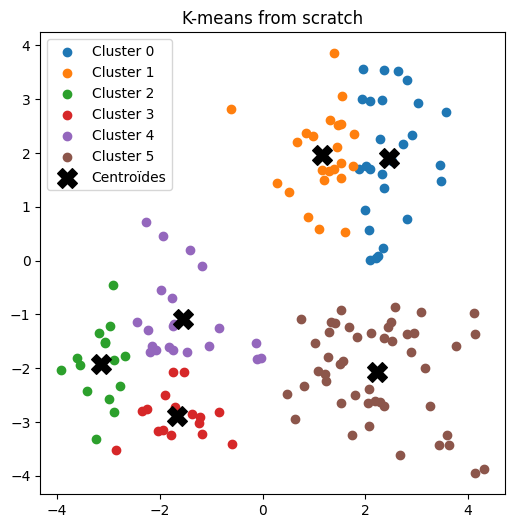

In [57]:
plt.figure(figsize=(6, 6))

for i in range(k):
    plt.scatter(X[clusters == i][:, 0],
                X[clusters == i][:, 1],
                label=f"Cluster {i}")

plt.scatter(centroides[:, 0],
            centroides[:, 1],
            color="black",
            marker="X",
            s=200,
            label="Centroïdes")

plt.legend()
plt.title("K-means from scratch")
plt.show()
